In [1]:
#Setup
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR = Path("")
TRAIN_DIR = DATA_DIR / "train"
TEST_DIR = DATA_DIR / "test"
LABELS = DATA_DIR / "labeled_anomalies.csv"

In [2]:
#1. Labeled anomalies
df = pd.read_csv(LABELS)
print(f"Labeled anomalies CSV: {len(df)} rows")
print(f"Columns: {list(df.columns)}")
print(f"Spacecraft breakdown:\n{df['spacecraft'].value_counts()}")
print(f"Unique channels: {df['chan_id'].nunique()}")
print()

Labeled anomalies CSV: 82 rows
Columns: ['chan_id', 'spacecraft', 'anomaly_sequences', 'class', 'num_values']
Spacecraft breakdown:
spacecraft
SMAP    55
MSL     27
Name: count, dtype: int64
Unique channels: 81



In [3]:
#2. Channel files
train_files = sorted(TRAIN_DIR.glob("*.npy"))
test_files = sorted(TEST_DIR.glob("*.npy"))
print(f"Channels: train={len(train_files)}, test={len(test_files)}")

Channels: train=82, test=82


In [4]:
#3. Inspect a sample channel
sample_chan = "A-1"  #SMAP channel, well-known
train = np.load(TRAIN_DIR / f"{sample_chan}.npy")
test = np.load(TEST_DIR / f"{sample_chan}.npy")
print(f"\nSample channel {sample_chan}:")
print(f"train shape: {train.shape}  (timesteps, features)")
print(f"test shape: {test.shape}")
print(f"train range: [{train[:, 0].min():.3f}, {train[:, 0].max():.3f}]")
print(f"test range: [{test[:, 0].min():.3f}, {test[:, 0].max():.3f}]")
print(f"feature 0 is the telemetry value to predict;")
print(f"features 1..{train.shape[1]-1} are encoded command information.")


Sample channel A-1:
train shape: (2880, 25)  (timesteps, features)
test shape: (8640, 25)
train range: [0.999, 0.999]
test range: [-1.000, 1.000]
feature 0 is the telemetry value to predict;
features 1..24 are encoded command information.


In [5]:
#4. Get this channel's anomaly intervals
row = df[df["chan_id"] == sample_chan].iloc[0]
print(f"\nAnomaly sequences for {sample_chan}: {row['anomaly_sequences']}")
print(f" (these are [start, end] index ranges into the *test* array)")


Anomaly sequences for A-1: [[4690, 4774]]
 (these are [start, end] index ranges into the *test* array)


In [6]:
#5. Total timesteps across all channels
total_train = sum(np.load(f).shape[0] for f in train_files)
total_test = sum(np.load(f).shape[0] for f in test_files)
print(f"\nTotal timesteps: train={total_train:,}  test={total_test:,}")
print(f"Total: ~{(total_train+total_test)/1e3:.0f}K timesteps")


Total timesteps: train=196,746  test=510,225
Total: ~707K timesteps


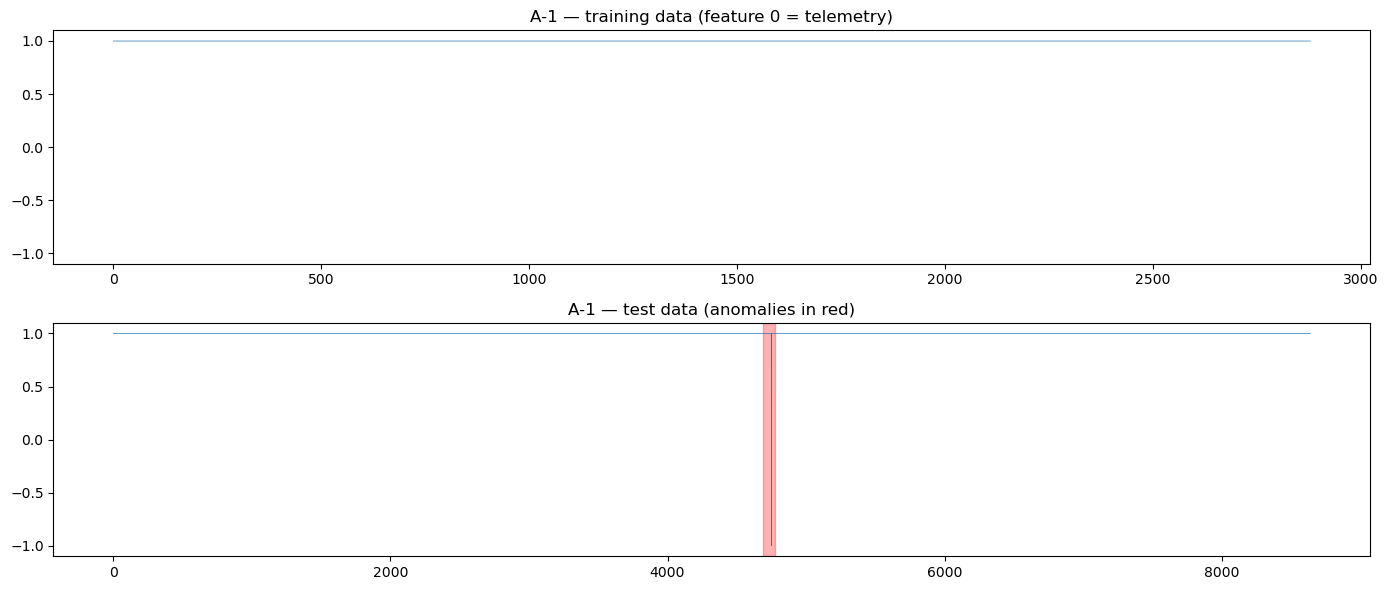

In [7]:
#6. Plot the sample channel
fig, ax = plt.subplots(2, 1, figsize=(14, 6), sharex=False)
ax[0].plot(train[:, 0], lw=0.5)
ax[0].set_title(f"{sample_chan} — training data (feature 0 = telemetry)")
ax[0].set_ylim(-1.1, 1.1)
ax[1].plot(test[:, 0], lw=0.5)
#overlay anomaly regions
anomalies = eval(row["anomaly_sequences"])  # it's a string of a list
for (s, e) in anomalies:
    ax[1].axvspan(s, e, color="red", alpha=0.3)
ax[1].set_title(f"{sample_chan} — test data (anomalies in red)")
ax[1].set_ylim(-1.1, 1.1)
plt.tight_layout()